# summarize the results of sensitivity analysis

Filtering: Keeping data where mu == 0.8
Scanning 28 directories...
Data Loaded. Count: 142

=== Mean and 95% Confidence Interval ===
Topology: BA    | epsilon_s: 0.3 | Mean:   -3.224 | 95% CI: ±2.650
Topology: BA    | epsilon_s: 0.4 | Mean:   -3.086 | 95% CI: ±3.853
Topology: BA    | epsilon_s: 0.5 | Mean:   -1.944 | 95% CI: ±1.711
Topology: BA    | epsilon_s: 0.6 | Mean:   -3.000 | 95% CI: ±2.547
Topology: BA    | epsilon_s: 0.7 | Mean:   -2.593 | 95% CI: ±2.323
Topology: CNNR  | epsilon_s: 0.3 | Mean:   -3.252 | 95% CI: ±2.044
Topology: CNNR  | epsilon_s: 0.4 | Mean:   -3.915 | 95% CI: ±1.838
Topology: CNNR  | epsilon_s: 0.5 | Mean:   -2.515 | 95% CI: ±2.116
Topology: CNNR  | epsilon_s: 0.6 | Mean:   -2.670 | 95% CI: ±2.023
Topology: CNNR  | epsilon_s: 0.7 | Mean:   -2.321 | 95% CI: ±1.369
Topology: ER    | epsilon_s: 0.3 | Mean:    0.318 | 95% CI: ±0.397
Topology: ER    | epsilon_s: 0.4 | Mean:    0.325 | 95% CI: ±0.255
Topology: ER    | epsilon_s: 0.5 | Mean:   -0.138 | 95% CI: ±0.

/var/folders/02/0ym8ylh51y3bbbn3ymbmr4j80000gq/T/ipykernel_75190/2744133840.py:164: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  ax = sns.lineplot(


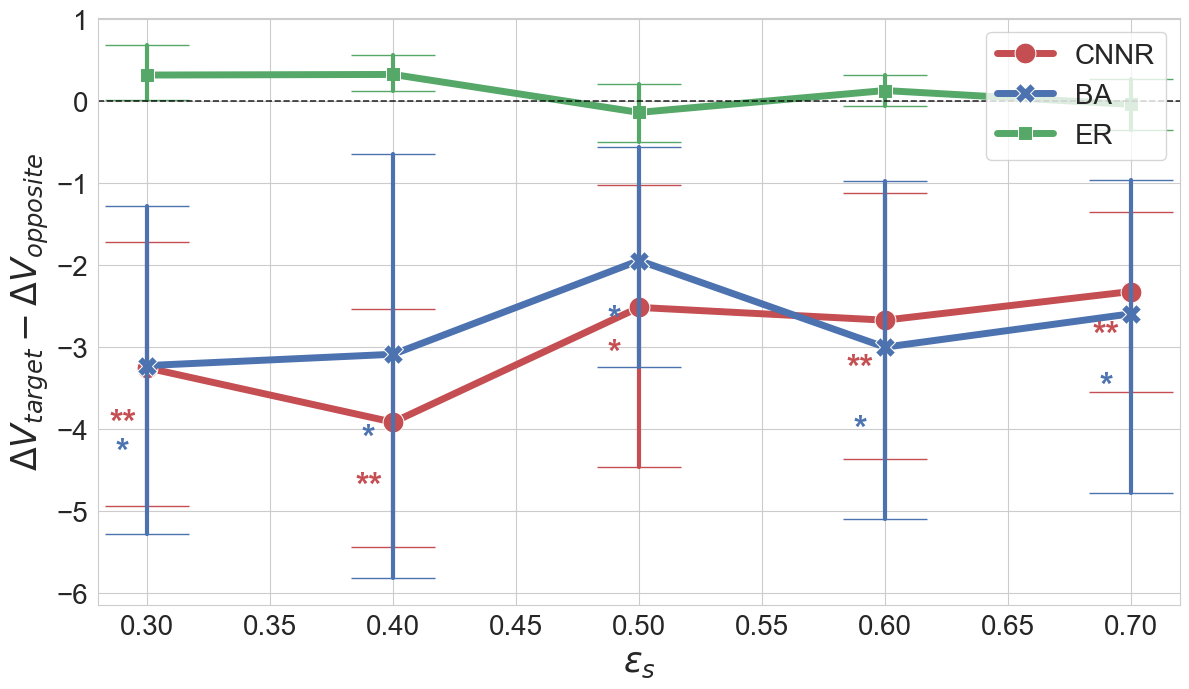

In [1]:
import os
import glob
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ==========================================
# 1. 設定 (Configuration)
# ==========================================
SUMMARY_ROOT = "./results/summary"

# ★ ここを変更すると分析対象が切り替わります ("mu" or "epsilon_s")
TARGET_PARAM = "epsilon_s"  # 分析対象のパラメータ名
#TARGET_PARAM = "mu"

# 集計期間
RANGE_EARLY = (19000, 20000)
RANGE_LATE  = (39000, 40000)

# 固定パラメータの条件定義
# "mu" を分析するとき -> epsilon_s は 0.5 に固定
# "epsilon_s" を分析するとき -> mu は 0.8 に固定
CONDITIONS = {
    "mu":        {"fixed_key": "epsilon_s", "fixed_val": 0.5},
    "epsilon_s": {"fixed_key": "mu",        "fixed_val": 0.8}
}

# ==========================================
# 2. データ読み込み (Seed単位・フィルタリング付き)
# ==========================================
def load_filtered_data(root_dir, target_param):
    data_records = []
    
    # 条件取得
    condition = CONDITIONS.get(target_param)
    if condition is None:
        print(f"Warning: No fixed condition defined for {target_param}. Loading all data.")
    else:
        print(f"Filtering: Keeping data where {condition['fixed_key']} == {condition['fixed_val']}")

    # ディレクトリ探索
    search_path = os.path.join(root_dir, "*", "*", "*")
    exp_dirs = glob.glob(search_path)
    
    print(f"Scanning {len(exp_dirs)} directories...")
    
    for d in exp_dirs:
        config_path = os.path.join(d, "config.yaml")
        csv_path = os.path.join(d, "post_timeseries.csv")
        
        if not (os.path.exists(config_path) and os.path.exists(csv_path)):
            continue
            
        try:
            with open(config_path, 'r') as f:
                config = yaml.safe_load(f)
            
            # --- フィルタリング処理 ---
            if condition:
                config_val = config.get(condition['fixed_key'])
                # float同士の比較なので、微小な誤差を許容するために np.isclose を使うか、
                # シンプルに一致を見るか。ここでは安全のため文字列化して比較するか、近似比較を行う
                if config_val is None or not np.isclose(float(config_val), condition['fixed_val']):
                    continue

            # トポロジー名取得
            path_parts = os.path.normpath(d).split(os.sep)
            topology = path_parts[-3] 
            if "topology" in config: topology = config["topology"]
            
            # 横軸パラメータ値
            if target_param not in config: continue
            param_value = config[target_param]
            
            # CSV読み込み
            df_ts = pd.read_csv(csv_path)
            
            # Seedごとに集計
            for seed, grp in df_ts.groupby("seed"):
                # Early / Late 抽出
                grp_early = grp[(grp['step'] >= RANGE_EARLY[0]) & (grp['step'] <= RANGE_EARLY[1])]
                grp_late  = grp[(grp['step'] >= RANGE_LATE[0])  & (grp['step'] <= RANGE_LATE[1])]
                
                if grp_early.empty or grp_late.empty: continue
                
                # 投稿数計算
                cols_target = ['target_extreme', 'target_mod']
                cols_opp    = ['opposite_extreme', 'opposite_mod']
                
                val_early_tar = grp_early[cols_target].sum(axis=1).mean()
                val_late_tar  = grp_late[cols_target].sum(axis=1).mean()
                
                val_early_opp = grp_early[cols_opp].sum(axis=1).mean()
                val_late_opp  = grp_late[cols_opp].sum(axis=1).mean()
                
                # 指標: Target増加分 - Opposite増加分
                metric = (val_late_tar - val_early_tar) - (val_late_opp - val_early_opp)
                
                data_records.append({
                    "Topology": topology,
                    target_param: param_value,
                    "seed": seed,
                    "Backfire_Metric": metric
                })
                
        except Exception as e:
            continue

    return pd.DataFrame(data_records)

# ==========================================
# 3. 実行・検定・プロット
# ==========================================
df_seeds = load_filtered_data(SUMMARY_ROOT, TARGET_PARAM)

if df_seeds.empty:
    print("No data found matching the criteria.")
else:
    print(f"Data Loaded. Count: {len(df_seeds)}")
    
    # --- 統計検定 (Target < Opposite => Metric < 0) ---
    stats_results = []
    for (topo, param_val), group in df_seeds.groupby(["Topology", TARGET_PARAM]):
        # 1-sample t-test (Less than 0)
        t_stat, p_val = stats.ttest_1samp(group["Backfire_Metric"], 0, alternative='less')
        
        stats_results.append({
            "Topology": topo,
            TARGET_PARAM: param_val,
            "Mean_Metric": group["Backfire_Metric"].mean(),
            "p_value": p_val
        })
    df_stats = pd.DataFrame(stats_results)

    print("\n=== Mean and 95% Confidence Interval ===")
    for (topo, param_val), group in df_seeds.groupby(["Topology", TARGET_PARAM]):
        vals = group["Backfire_Metric"].dropna()
        n = len(vals)
        mean_val = vals.mean()
        
        if n > 1:
            # 標準誤差(SEM)とt分布を用いた95%信頼区間の半値幅(Margin of error)を計算
            sem = stats.sem(vals)
            ci_margin = stats.t.ppf(1 - 0.05 / 2, n - 1) * sem
            print(f"Topology: {topo:<5} | {TARGET_PARAM}: {param_val} | Mean: {mean_val:>8.3f} | 95% CI: ±{ci_margin:.3f}")
        else:
            print(f"Topology: {topo:<5} | {TARGET_PARAM}: {param_val} | Mean: {mean_val:>8.3f} | 95% CI: N/A (n={n})")
    print("=========================================\n")

    # --- 可視化 ---
    sns.set_style("whitegrid")

    # --- 可視化 ---
    sns.set_style("whitegrid")
    plt.figure(figsize=(12, 7))
    
    # 色の設定
    palette = {"CNNR": "#c44e52", "BA": "#4c72b0", "ER": "#55a868"}

    # エラーバー付きラインプロット
    ax = sns.lineplot(
        data=df_seeds,
        x=TARGET_PARAM,
        y="Backfire_Metric",
        hue="Topology",
        style="Topology",
        markers=True,
        dashes=False,
        linewidth=5,
        markersize=15,
        palette=palette,
        err_style="bars",        
        err_kws={'capsize': 30, 'elinewidth': 3},
        ci=95
    )
    
    # ★ 変更箇所: オフセット設定
    # X軸方向: 全て -0.005
    fixed_x_offset = -0.01
    
    # Y軸方向: トポロジーごとに「データ点からどれくらい離すか」を変える
    # 係数を変えることで高さをずらす (CNNRは近く、ERは遠くなど)
    y_offset_factors = {"CNNR": 1.0, "BA": 1.8, "ER": 2.6}
    
    for _, row in df_stats.iterrows():
        p = row["p_value"]
        x = row[TARGET_PARAM]
        y = row["Mean_Metric"]
        topo = row["Topology"]
        
        if p < 0.05:
            marker = "**" if p < 0.01 else "*"
            
            # 基準となるYオフセット量 (値の大きさに応じて調整)
            base_dist = 0.5 if abs(y) < 1.0 else abs(y) * 0.15
            
            # トポロジーごとの係数を掛けて、Y位置を決定
            # プロット点(y)から下方向へずらす
            y_pos = y - (base_dist * y_offset_factors.get(topo, 1.0))
            
            # X位置
            x_pos = x + fixed_x_offset
            
            plt.text(x_pos, y_pos, marker, 
                     ha='center', va='top', # 点の下にぶら下げる形
                     fontsize=25, 
                     color=palette.get(topo, 'black'), 
                     fontweight='bold')

    # ゼロライン
    plt.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
    
    # タイトルなど
    fixed_cond = CONDITIONS.get(TARGET_PARAM)
    subtitle = f"(Fixed: {fixed_cond['fixed_key']}={fixed_cond['fixed_val']})" if fixed_cond else ""
    
    #plt.title(f"Sensitivity Analysis: Backfire Effect vs {TARGET_PARAM}\n{subtitle}", fontsize=16)
    plt.xlabel(r"$\epsilon_s$", fontsize=25)
    #plt.xlabel(r"$\mu_{stub}$", fontsize=25)
    plt.ylabel(r"$\Delta V_{target} - \Delta V_{opposite}$", fontsize=25)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.legend(fontsize=20, loc='upper right')
    
    plt.tight_layout()
    plt.savefig(f"SA_results_{TARGET_PARAM}.png")
    plt.show()

Filtering: Keeping data where mu == 0.8
Scanning 26 directories...
Data Loaded. Count: 88

=== Mean and 95% Confidence Interval ===
Topology: BA    | epsilon_s: 0.3 | Mean:   -3.224 | 95% CI: ±2.650
Topology: BA    | epsilon_s: 0.5 | Mean:   -1.944 | 95% CI: ±1.711
Topology: BA    | epsilon_s: 0.7 | Mean:   -2.593 | 95% CI: ±2.323
Topology: CNNR  | epsilon_s: 0.3 | Mean:   -3.252 | 95% CI: ±2.044
Topology: CNNR  | epsilon_s: 0.5 | Mean:   -2.515 | 95% CI: ±2.116
Topology: CNNR  | epsilon_s: 0.7 | Mean:   -2.321 | 95% CI: ±1.369
Topology: ER    | epsilon_s: 0.3 | Mean:    0.318 | 95% CI: ±0.397
Topology: ER    | epsilon_s: 0.5 | Mean:   -0.138 | 95% CI: ±0.452
Topology: ER    | epsilon_s: 0.7 | Mean:   -0.040 | 95% CI: ±0.370



/var/folders/02/0ym8ylh51y3bbbn3ymbmr4j80000gq/T/ipykernel_72286/3689673489.py:166: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  ax = sns.lineplot(


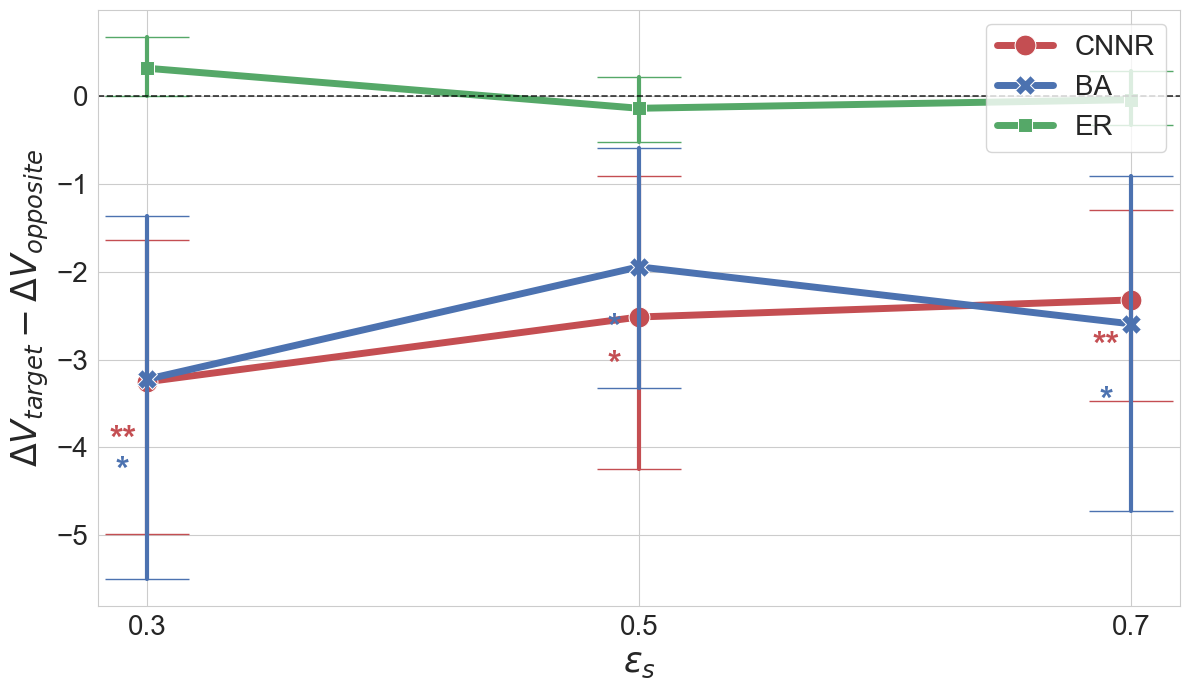

In [1]:
import os
import glob
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ==========================================
# 1. 設定 (Configuration)
# ==========================================
SUMMARY_ROOT = "./results/summary"

# ★ ここを変更すると分析対象が切り替わります ("mu" or "epsilon_s")
TARGET_PARAM = "epsilon_s"  # 分析対象のパラメータ名
#TARGET_PARAM = "mu"

# 集計期間
RANGE_EARLY = (19000, 20000)
RANGE_LATE  = (39000, 40000)

# 固定パラメータの条件定義
# "mu" を分析するとき -> epsilon_s は 0.5 に固定
# "epsilon_s" を分析するとき -> mu は 0.8 に固定
CONDITIONS = {
    "mu":        {"fixed_key": "epsilon_s", "fixed_val": 0.5},
    "epsilon_s": {"fixed_key": "mu",        "fixed_val": 0.8}
}

# ==========================================
# 2. データ読み込み (Seed単位・フィルタリング付き)
# ==========================================
def load_filtered_data(root_dir, target_param):
    data_records = []
    
    # 条件取得
    condition = CONDITIONS.get(target_param)
    if condition is None:
        print(f"Warning: No fixed condition defined for {target_param}. Loading all data.")
    else:
        print(f"Filtering: Keeping data where {condition['fixed_key']} == {condition['fixed_val']}")

    # ディレクトリ探索
    search_path = os.path.join(root_dir, "*", "*", "*")
    exp_dirs = glob.glob(search_path)
    
    print(f"Scanning {len(exp_dirs)} directories...")
    
    for d in exp_dirs:
        config_path = os.path.join(d, "config.yaml")
        csv_path = os.path.join(d, "post_timeseries.csv")
        
        if not (os.path.exists(config_path) and os.path.exists(csv_path)):
            continue
            
        try:
            with open(config_path, 'r') as f:
                config = yaml.safe_load(f)
            
            # --- フィルタリング処理 ---
            if condition:
                config_val = config.get(condition['fixed_key'])
                if config_val is None or not np.isclose(float(config_val), condition['fixed_val']):
                    continue

            # トポロジー名取得
            path_parts = os.path.normpath(d).split(os.sep)
            topology = path_parts[-3] 
            if "topology" in config: topology = config["topology"]
            
            # 横軸パラメータ値
            if target_param not in config: continue
            param_value = config[target_param]
            
            # ★ 追加箇所: epsilon_s の場合は 0.3, 0.5, 0.7 のみを取得
            if target_param == "epsilon_s":
                allowed_epsilons = [0.3, 0.5, 0.7]
                # 浮動小数点数の誤差を考慮して np.isclose で判定
                if not any(np.isclose(float(param_value), val) for val in allowed_epsilons):
                    continue
            
            # CSV読み込み
            df_ts = pd.read_csv(csv_path)
            
            # Seedごとに集計
            for seed, grp in df_ts.groupby("seed"):
                # Early / Late 抽出
                grp_early = grp[(grp['step'] >= RANGE_EARLY[0]) & (grp['step'] <= RANGE_EARLY[1])]
                grp_late  = grp[(grp['step'] >= RANGE_LATE[0])  & (grp['step'] <= RANGE_LATE[1])]
                
                if grp_early.empty or grp_late.empty: continue
                
                # 投稿数計算
                cols_target = ['target_extreme', 'target_mod']
                cols_opp    = ['opposite_extreme', 'opposite_mod']
                
                val_early_tar = grp_early[cols_target].sum(axis=1).mean()
                val_late_tar  = grp_late[cols_target].sum(axis=1).mean()
                
                val_early_opp = grp_early[cols_opp].sum(axis=1).mean()
                val_late_opp  = grp_late[cols_opp].sum(axis=1).mean()
                
                # 指標: Target増加分 - Opposite増加分
                metric = (val_late_tar - val_early_tar) - (val_late_opp - val_early_opp)
                
                data_records.append({
                    "Topology": topology,
                    target_param: param_value,
                    "seed": seed,
                    "Backfire_Metric": metric
                })
                
        except Exception as e:
            continue

    return pd.DataFrame(data_records)

# ==========================================
# 3. 実行・検定・プロット
# ==========================================
df_seeds = load_filtered_data(SUMMARY_ROOT, TARGET_PARAM)

if df_seeds.empty:
    print("No data found matching the criteria.")
else:
    print(f"Data Loaded. Count: {len(df_seeds)}")
    
    # --- 統計検定 (Target < Opposite => Metric < 0) ---
    stats_results = []
    for (topo, param_val), group in df_seeds.groupby(["Topology", TARGET_PARAM]):
        # 1-sample t-test (Less than 0)
        t_stat, p_val = stats.ttest_1samp(group["Backfire_Metric"], 0, alternative='less')
        
        stats_results.append({
            "Topology": topo,
            TARGET_PARAM: param_val,
            "Mean_Metric": group["Backfire_Metric"].mean(),
            "p_value": p_val
        })
    df_stats = pd.DataFrame(stats_results)

    print("\n=== Mean and 95% Confidence Interval ===")
    for (topo, param_val), group in df_seeds.groupby(["Topology", TARGET_PARAM]):
        vals = group["Backfire_Metric"].dropna()
        n = len(vals)
        mean_val = vals.mean()
        
        if n > 1:
            # 標準誤差(SEM)とt分布を用いた95%信頼区間の半値幅(Margin of error)を計算
            sem = stats.sem(vals)
            ci_margin = stats.t.ppf(1 - 0.05 / 2, n - 1) * sem
            print(f"Topology: {topo:<5} | {TARGET_PARAM}: {param_val} | Mean: {mean_val:>8.3f} | 95% CI: ±{ci_margin:.3f}")
        else:
            print(f"Topology: {topo:<5} | {TARGET_PARAM}: {param_val} | Mean: {mean_val:>8.3f} | 95% CI: N/A (n={n})")
    print("=========================================\n")

    # --- 可視化 ---
    sns.set_style("whitegrid")
    plt.figure(figsize=(12, 7))
    
    # 色の設定
    palette = {"CNNR": "#c44e52", "BA": "#4c72b0", "ER": "#55a868"}

    # エラーバー付きラインプロット
    ax = sns.lineplot(
        data=df_seeds,
        x=TARGET_PARAM,
        y="Backfire_Metric",
        hue="Topology",
        style="Topology",
        markers=True,
        dashes=False,
        linewidth=5,
        markersize=15,
        palette=palette,
        err_style="bars",        
        err_kws={'capsize': 30, 'elinewidth': 3},
        ci=95
    )
    
    # オフセット設定
    # X軸方向: 全て -0.01
    fixed_x_offset = -0.01
    
    # Y軸方向: トポロジーごとに「データ点からどれくらい離すか」を変える
    y_offset_factors = {"CNNR": 1.0, "BA": 1.8, "ER": 2.6}
    
    for _, row in df_stats.iterrows():
        p = row["p_value"]
        x = row[TARGET_PARAM]
        y = row["Mean_Metric"]
        topo = row["Topology"]
        
        if p < 0.05:
            marker = "**" if p < 0.01 else "*"
            
            # 基準となるYオフセット量 (値の大きさに応じて調整)
            base_dist = 0.5 if abs(y) < 1.0 else abs(y) * 0.15
            
            # トポロジーごとの係数を掛けて、Y位置を決定
            y_pos = y - (base_dist * y_offset_factors.get(topo, 1.0))
            
            # X位置
            x_pos = x + fixed_x_offset
            
            plt.text(x_pos, y_pos, marker, 
                     ha='center', va='top', 
                     fontsize=25, 
                     color=palette.get(topo, 'black'), 
                     fontweight='bold')

    # ゼロライン
    plt.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
    
    # タイトルなど
    fixed_cond = CONDITIONS.get(TARGET_PARAM)
    subtitle = f"(Fixed: {fixed_cond['fixed_key']}={fixed_cond['fixed_val']})" if fixed_cond else ""
    
    plt.xlabel(r"$\epsilon_s$", fontsize=25)
    plt.ylabel(r"$\Delta V_{target} - \Delta V_{opposite}$", fontsize=25)
    plt.xticks([0.3, 0.5, 0.7], fontsize=20) # ★ X軸の目盛りも 0.3, 0.5, 0.7 に固定すると見やすくなります
    plt.yticks(fontsize=20)
    plt.legend(fontsize=20, loc='upper right')
    
    plt.tight_layout()
    plt.savefig(f"SA_results_{TARGET_PARAM}.png")
    plt.show()